# Email Network Community Detection and Role Discovery

## Goal

This notebook applies unsupervised graph analysis to an institutional email network.

Each node represents a member of a research institution, and each edge represents an email communication relationship.

The project aims to discover:

- hidden communication communities
- highly influential members
- local community hubs
- bridge members connecting different communities
- interaction patterns between communities

Traditional clustering treats observations as independent rows.

In this project, community membership is discovered entirely from network connections. A person's position depends on who they communicate with and how those contacts connect to the rest of the organisation.

## Important note

Department labels are not used during community detection.

They are only used after the unsupervised analysis to check whether the discovered communication communities resemble known organisational departments.

In [1]:
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.datasets import EmailEUCore
from torch_geometric.utils import to_networkx

from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("NetworkX version:", nx.__version__)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


NetworkX version: 3.2.1


In [2]:
dataset = EmailEUCore(
    root="data/EmailEUCore"
)

data = dataset[0]

print(dataset)
print(data)

Extracting data\EmailEUCore\raw\email-Eu-core.txt.gz


EmailEUCore()
Data(edge_index=[2, 25571], y=[1005], num_nodes=1005)


Extracting data\EmailEUCore\raw\email-Eu-core-department-labels.txt.gz
Processing...
Done!


In [3]:
department_labels = data.y.cpu().numpy()

print("PyG node count:", data.num_nodes)
print("PyG edge entries:", data.num_edges)
print("Department labels:", len(np.unique(department_labels)))

PyG node count: 1005
PyG edge entries: 25571
Department labels: 42


## Data loading 

The dataset contains 1,005 institutional members and 25,571 directed email edge entries.

Each member has one of 42 known department labels. These labels were retained only for post-hoc evaluation and were not used by the Louvain community detection algorithm.

The analysis therefore discovered communication groups entirely from the email network structure.

In [4]:
G = to_networkx(
    data,
    to_undirected=True,
    remove_self_loops=True
)

G = nx.Graph(G)

G.remove_edges_from(
    list(nx.selfloop_edges(G))
)

print("Nodes:", G.number_of_nodes())
print("Undirected edges:", G.number_of_edges())

Nodes: 1005
Undirected edges: 16064


In [5]:
connected_components = list(
    nx.connected_components(G)
)

largest_component_nodes = max(
    connected_components,
    key=len
)

graph_summary = pd.DataFrame({
    "property": [
        "Nodes",
        "Undirected edges",
        "Connected components",
        "Largest component nodes",
        "Largest component share",
        "Graph density",
        "Average clustering coefficient"
    ],
    "value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.number_connected_components(G),
        len(largest_component_nodes),
        len(largest_component_nodes) / G.number_of_nodes(),
        nx.density(G),
        nx.average_clustering(G)
    ]
})

graph_summary

,property,value
0,Nodes,1005.000000
1,Undirected edges,16064.000000
2,Connected components,20.000000
3,Largest component nodes,986.000000
4,Largest component share,0.981095
5,Graph density,0.031841
6,Average clustering coefficient,0.399355


## Graph construction 

After converting the directed email data into an undirected graph and merging reciprocal relationships, the network contained 1,005 nodes and 16,064 unique edges.

The graph had 20 connected components. The largest component contained 986 members, representing 98.11% of the network, while the remaining 19 members were isolated nodes.

The graph density was only 0.0318, showing that members communicated with a small fraction of all possible contacts. However, the average clustering coefficient was 0.3994, indicating that local communication circles were relatively well connected.

In [6]:
degree_values = np.array([
    degree
    for _, degree in G.degree()
])

pd.Series(
    degree_values,
    name="degree"
).describe()

count    1005.000000
mean       31.968159
std        36.959747
min         0.000000
25%         6.000000
50%        21.000000
75%        44.000000
max       345.000000
Name: degree, dtype: float64

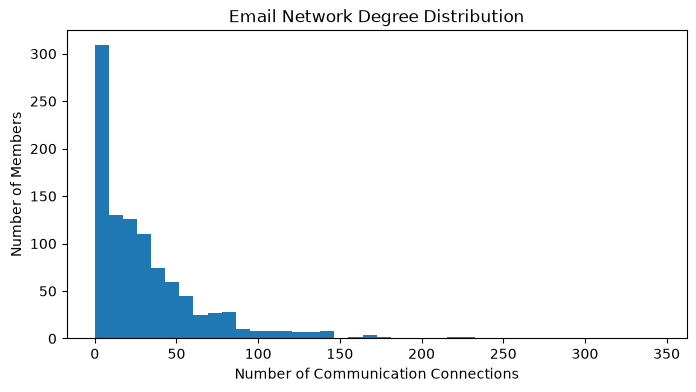

In [7]:
plt.figure(figsize=(8, 4))

plt.hist(
    degree_values,
    bins=40
)

plt.title("Email Network Degree Distribution")
plt.xlabel("Number of Communication Connections")
plt.ylabel("Number of Members")
plt.show()

In [8]:
degree_table = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [
        G.degree(node)
        for node in G.nodes()
    ],
    "department": [
        department_labels[node]
        for node in G.nodes()
    ]
}).sort_values(
    "degree",
    ascending=False
)

degree_table.head(15)

,node,degree,department
160,160,345,36
121,121,232,36
82,82,231,36
107,107,219,36
86,86,216,36
62,62,214,36
434,434,183,34
13,13,178,26
166,166,175,36
183,183,171,4


## Degree distribution 

The degree distribution was strongly right-skewed.

Members had:

- Mean degree: 31.97
- Median degree: 21
- 75th percentile: 44
- Maximum degree: 345

Most members communicated with a relatively small number of colleagues, while a small number of highly connected nodes acted as network hubs.

Node 160 had the highest degree, with 345 communication connections. High degree indicates broad activity, but it does not automatically mean that a member connects several different communities.

In [9]:
communities = nx.community.louvain_communities(
    G,
    resolution=1.0,
    seed=RANDOM_STATE
)

communities = sorted(
    communities,
    key=len,
    reverse=True
)

print("Number of communities:", len(communities))

Number of communities: 28


In [10]:
node_to_community = {}

for community_id, nodes in enumerate(communities):
    for node in nodes:
        node_to_community[node] = community_id

community_labels = np.array([
    node_to_community[node]
    for node in range(G.number_of_nodes())
])

In [11]:
louvain_modularity = nx.community.modularity(
    G,
    communities,
    resolution=1.0
)

community_sizes = pd.Series({
    community_id: len(nodes)
    for community_id, nodes in enumerate(communities)
}).sort_values(ascending=False)

print("Modularity:", round(louvain_modularity, 4))

community_sizes

Modularity: 0.413


0     190
1     157
2     145
3     127
4     125
5     109
6      91
7      32
8      10
9       1
10      1
11      1
12      1
13      1
14      1
15      1
16      1
17      1
18      1
19      1
20      1
21      1
22      1
23      1
24      1
25      1
26      1
27      1
dtype: int64

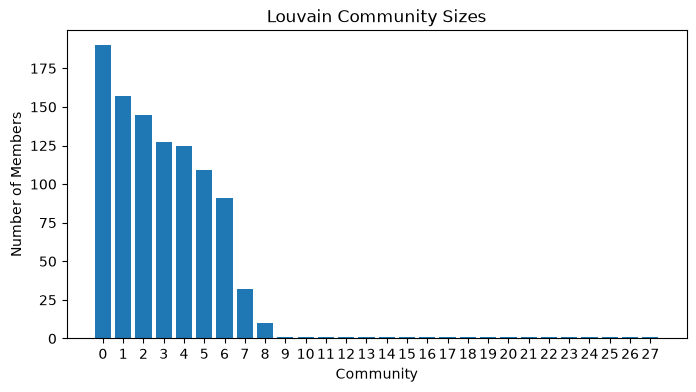

In [12]:
plt.figure(figsize=(8, 4))

plt.bar(
    community_sizes.index.astype(str),
    community_sizes.values
)

plt.title("Louvain Community Sizes")
plt.xlabel("Community")
plt.ylabel("Number of Members")
plt.show()

## Louvain communities 

Louvain detected 28 communities with a modularity of 0.4130.

The largest community contained 190 members. The next-largest communities contained 157, 145, 127, 125, 109, and 91 members.

Only nine communities contained more than one member. The other 19 communities were single isolated nodes, corresponding to the members outside the main connected component.

The modularity score indicates meaningful community organisation, although the groups were not completely separated from one another.

In [13]:
layout = nx.spring_layout(
    G,
    seed=RANDOM_STATE,
    iterations=80,
    k=0.12
)

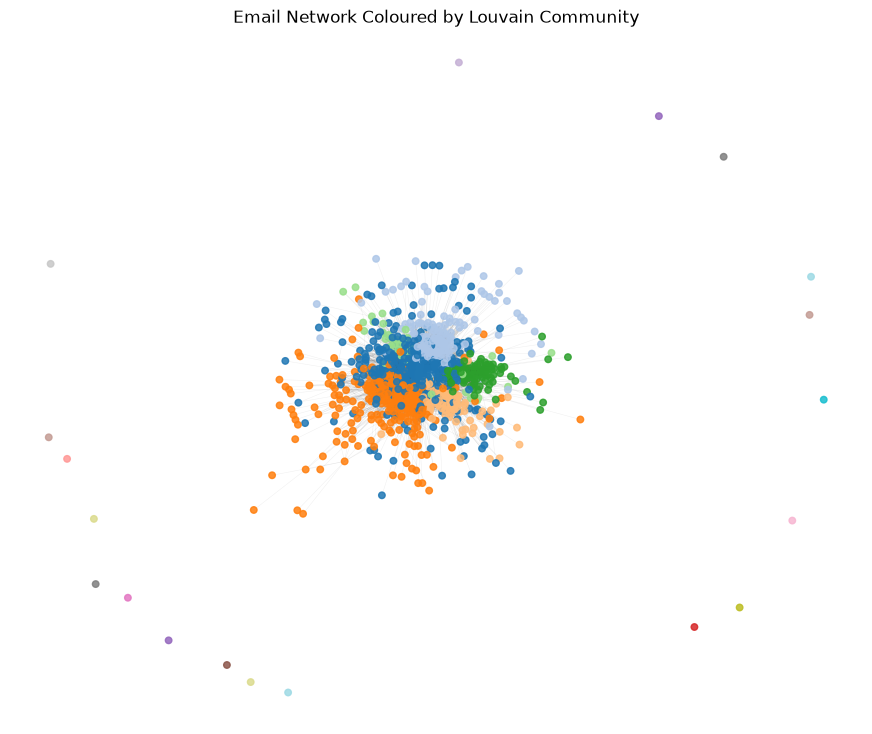

In [14]:
plt.figure(figsize=(11, 9))

nx.draw_networkx_edges(
    G,
    pos=layout,
    alpha=0.06,
    width=0.4
)

nx.draw_networkx_nodes(
    G,
    pos=layout,
    node_color=[
        node_to_community[node]
        for node in G.nodes()
    ],
    cmap=plt.cm.tab20,
    node_size=22,
    alpha=0.85
)

plt.title("Email Network Coloured by Louvain Community")
plt.axis("off")
plt.show()

## Network visualisation 

The network visualisation shows one dense central component containing most institutional members.

Several colour-specific communication regions are visible, but the major communities also overlap and remain connected through many cross-community edges. This suggests that the organisation contains recognisable working groups without being divided into fully isolated sections.

The isolated nodes appear around the outside of the visualisation as separate one-member communities.

The spring layout is only used for visualisation and does not determine the Louvain community assignments.

In [15]:
internal_edges = 0
external_edges = 0

for source, target in G.edges():
    if (
        node_to_community[source]
        == node_to_community[target]
    ):
        internal_edges += 1
    else:
        external_edges += 1

internal_edge_rate = (
    internal_edges / G.number_of_edges()
)

edge_structure_df = pd.DataFrame({
    "edge_type": [
        "Within community",
        "Between communities"
    ],
    "edges": [
        internal_edges,
        external_edges
    ],
    "percentage": [
        internal_edge_rate * 100,
        (1 - internal_edge_rate) * 100
    ]
})

edge_structure_df

,edge_type,edges,percentage
0,Within community,9046,56.312251
1,Between communities,7018,43.687749


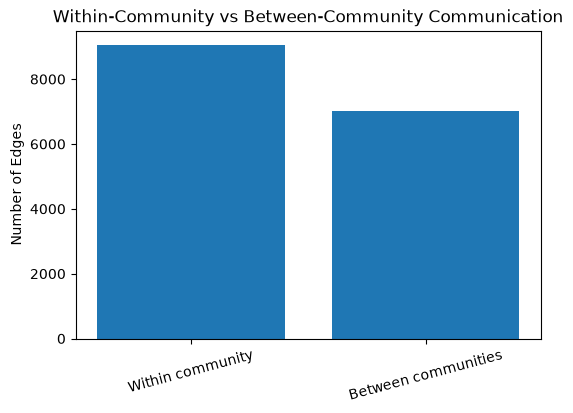

In [16]:
plt.figure(figsize=(6, 4))

plt.bar(
    edge_structure_df["edge_type"],
    edge_structure_df["edges"]
)

plt.title("Within-Community vs Between-Community Communication")
plt.ylabel("Number of Edges")
plt.xticks(rotation=15)
plt.show()

## Internal communication 

The discovered partition contained:

- 9,046 within-community edges
- 7,018 between-community edges

Approximately 56.31% of communication relationships remained inside the same community, while 43.69% connected different communities.

This shows that communication was somewhat more concentrated within local groups, but cross-community interaction was still substantial. The organisation therefore did not consist of isolated communication silos.

In [18]:
resolution_values = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    2.00
]

resolution_rows = []

for resolution in resolution_values:
    resolution_communities = (
        nx.community.louvain_communities(
            G,
            resolution=resolution,
            seed=RANDOM_STATE
        )
    )

    resolution_sizes = [
        len(nodes)
        for nodes in resolution_communities
    ]

    resolution_rows.append({
        "resolution": resolution,
        "communities": len(
            resolution_communities
        ),
        "largest_community": max(
            resolution_sizes
        ),
        "median_community_size": np.median(
            resolution_sizes
        ),
        "modularity_at_resolution":
            nx.community.modularity(
                G,
                resolution_communities,
                resolution=resolution
            )
    })

resolution_df = pd.DataFrame(
    resolution_rows
)

resolution_df

,resolution,communities,largest_community,median_community_size,modularity_at_resolution
0,0.50,22,731,1.0,0.547844
1,0.75,25,343,1.0,0.471276
2,1.00,28,190,1.0,0.413021
3,1.25,30,144,1.0,0.379457
4,1.50,33,126,1.0,0.355466
5,2.00,44,110,5.5,0.316824


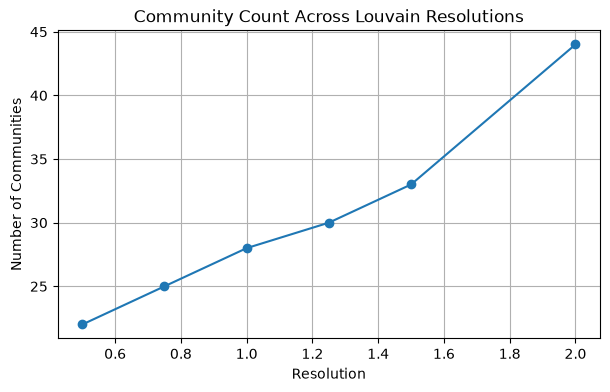

In [19]:
plt.figure(figsize=(7, 4))

plt.plot(
    resolution_df["resolution"],
    resolution_df["communities"],
    marker="o"
)

plt.title("Community Count Across Louvain Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Communities")
plt.grid(True)
plt.show()

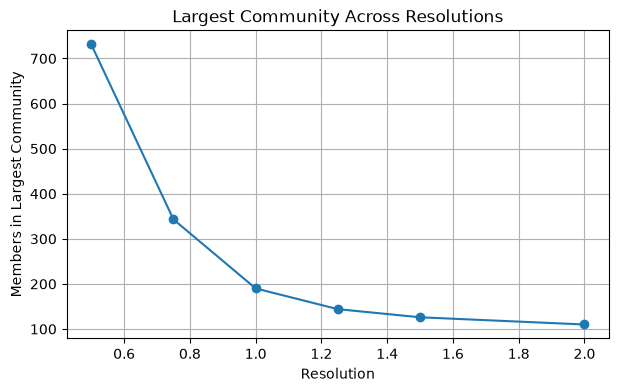

In [20]:
plt.figure(figsize=(7, 4))

plt.plot(
    resolution_df["resolution"],
    resolution_df["largest_community"],
    marker="o"
)

plt.title("Largest Community Across Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Members in Largest Community")
plt.grid(True)
plt.show()

## Resolution sensitivity 

The number and size of communities changed substantially with the Louvain resolution parameter.

| Resolution | Communities | Largest community |
|---:|---:|---:|
| 0.50 | 22 | 731 |
| 0.75 | 25 | 343 |
| 1.00 | 28 | 190 |
| 1.25 | 30 | 144 |
| 1.50 | 33 | 126 |
| 2.00 | 44 | 110 |

At resolution 0.50, most connected members were merged into one very large community of 731 nodes.

Increasing the resolution progressively divided the network into more detailed and smaller groups. The primary resolution of 1.00 provided a middle level of granularity, producing 28 total communities and a largest group of 190 members.

The modularity values reported at different resolutions correspond to different resolution-adjusted objectives, so they should not be treated as a simple performance ranking.

In [21]:
department_nmi = normalized_mutual_info_score(
    department_labels,
    community_labels
)

department_ari = adjusted_rand_score(
    department_labels,
    community_labels
)

print("Department NMI:", round(department_nmi, 4))
print("Department ARI:", round(department_ari, 4))

Department NMI: 0.5946
Department ARI: 0.3505


In [22]:
community_department_counts = pd.crosstab(
    pd.Series(
        community_labels,
        name="community"
    ),
    pd.Series(
        department_labels,
        name="department"
    )
)

community_department_counts

department,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
community,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,9,5,0,11,1,19,1,...,0,0,9,11,18,15,11,0,4,0
1,0,43,1,0,1,0,8,0,0,27,...,0,0,2,2,1,0,0,3,0,2
2,0,3,0,0,1,0,2,0,0,0,...,8,0,1,0,1,0,2,0,0,0
3,3,0,0,3,93,17,3,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,46,16,0,0,2,1,4,48,0,0,...,0,0,0,0,1,0,0,0,0,0
5,0,0,0,0,5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,8,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## Department alignment 

The discovered communities achieved:

- Normalized Mutual Information: 0.5946
- Adjusted Rand Index: 0.3505

The NMI indicates a meaningful relationship between communication communities and official departments. However, the lower ARI shows that the two partitions were far from a one-to-one match.

This suggests that formal departments influenced communication patterns, but employees also communicated through cross-department projects, shared responsibilities, and informal working relationships.

In [23]:
community_profile_rows = []

for community_id, nodes in enumerate(
    communities
):
    nodes = sorted(nodes)

    labels = department_labels[nodes]

    label_counts = pd.Series(
        labels
    ).value_counts()

    dominant_department = (
        label_counts.index[0]
    )

    dominant_count = (
        label_counts.iloc[0]
    )

    community_profile_rows.append({
        "community": community_id,
        "members": len(nodes),
        "departments_present":
            label_counts.size,
        "dominant_department":
            dominant_department,
        "dominant_department_members":
            dominant_count,
        "purity":
            dominant_count / len(nodes)
    })

community_profile_df = pd.DataFrame(
    community_profile_rows
).sort_values(
    "members",
    ascending=False
)

community_profile_df

,community,members,departments_present,dominant_department,dominant_department_members,purity
0,0,190,27,16,23,0.121053
1,1,157,20,15,44,0.280255
2,2,145,18,21,53,0.365517
3,3,127,12,4,93,0.732283
4,4,125,13,7,48,0.384000
5,5,109,12,10,38,0.348624
6,6,91,4,14,88,0.967033
7,7,32,2,17,31,0.968750
8,8,10,3,2,8,0.800000
9,9,1,1,16,1,1.000000


In [24]:
weighted_community_purity = (
    community_profile_df[
        "dominant_department_members"
    ].sum()
    / G.number_of_nodes()
)

mean_community_purity = (
    community_profile_df["purity"].mean()
)

print(
    "Weighted community purity:",
    round(weighted_community_purity, 4)
)

print(
    "Mean community purity:",
    round(mean_community_purity, 4)
)

Weighted community purity: 0.4428
Mean community purity: 0.856


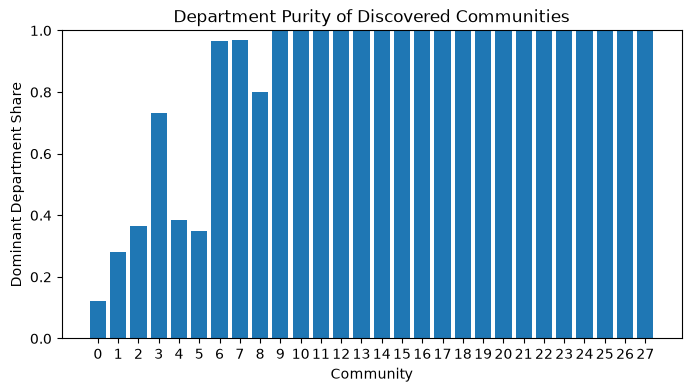

In [25]:
plt.figure(figsize=(8, 4))

plt.bar(
    community_profile_df[
        "community"
    ].astype(str),
    community_profile_df["purity"]
)

plt.title("Department Purity of Discovered Communities")
plt.xlabel("Community")
plt.ylabel("Dominant Department Share")
plt.ylim(0, 1)
plt.show()

## Community profiles 

The weighted community purity was 0.4428, meaning approximately 44.28% of all members belonged to the dominant department of their discovered community.

The larger communities were generally mixed:

- Community 0 contained 190 members from 27 departments and had purity of only 0.1211.
- Community 1 contained 157 members from 20 departments and had purity of 0.2803.
- Community 2 contained 145 members from 18 departments and had purity of 0.3655.

Some smaller communities aligned closely with formal departments:

- Community 6 contained 91 members from four departments and had purity of 0.9670.
- Community 7 contained 32 members from two departments and had purity of 0.9688.
- Community 8 contained 10 members from three departments and had purity of 0.8000.

The unweighted mean purity was 0.8560, but this value was inflated by the 19 singleton communities, which automatically had purity of 1.0. Weighted purity gives a more representative overall result.

In [26]:
role_rows = []

for node in G.nodes():
    node_degree = G.degree(node)
    node_community = node_to_community[node]

    neighbour_community_counts = Counter(
        node_to_community[neighbour]
        for neighbour in G.neighbors(node)
    )

    within_degree = (
        neighbour_community_counts.get(
            node_community,
            0
        )
    )

    external_degree = (
        node_degree - within_degree
    )

    if node_degree == 0:
        participation = 0.0
    else:
        participation = 1 - sum(
            (
                count / node_degree
            ) ** 2
            for count
            in neighbour_community_counts.values()
        )

    role_rows.append({
        "node": node,
        "department":
            department_labels[node],
        "community":
            node_community,
        "degree":
            node_degree,
        "within_degree":
            within_degree,
        "external_degree":
            external_degree,
        "participation":
            participation
    })

role_df = pd.DataFrame(role_rows)

In [27]:
def calculate_group_z_score(series):
    standard_deviation = series.std(ddof=0)

    if standard_deviation == 0:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index
        )

    return (
        series - series.mean()
    ) / standard_deviation


role_df["within_degree_z"] = (
    role_df
    .groupby("community")[
        "within_degree"
    ]
    .transform(
        calculate_group_z_score
    )
)

role_df.head()

,node,department,community,degree,within_degree,external_degree,participation,within_degree_z
0,0,1,1,42,22,20,0.667800,0.605823
1,1,1,1,50,26,24,0.643200,0.920250
2,2,21,2,93,63,30,0.508729,2.388060
3,3,21,2,69,48,21,0.482672,1.559798
4,4,21,2,94,59,35,0.559077,2.167190


In [28]:
degree_centrality = nx.degree_centrality(G)

pagerank_scores = nx.pagerank(G)

betweenness_scores = nx.betweenness_centrality(
    G,
    k=min(200, G.number_of_nodes()),
    seed=RANDOM_STATE,
    normalized=True
)

In [29]:
role_df["degree_centrality"] = (
    role_df["node"].map(
        degree_centrality
    )
)

role_df["pagerank"] = (
    role_df["node"].map(
        pagerank_scores
    )
)

role_df["betweenness"] = (
    role_df["node"].map(
        betweenness_scores
    )
)

In [30]:
def assign_network_role(row):
    is_hub = row["within_degree_z"] >= 2.0
    is_bridge = row["participation"] >= 0.60

    if is_hub and is_bridge:
        return "Connector hub"

    if is_hub:
        return "Community hub"

    if is_bridge:
        return "Bridge member"

    if row["participation"] <= 0.05:
        return "Peripheral member"

    return "Local connector"


role_df["network_role"] = role_df.apply(
    assign_network_role,
    axis=1
)

role_df["network_role"].value_counts()

network_role
Local connector      490
Bridge member        258
Peripheral member    217
Connector hub         28
Community hub         12
Name: count, dtype: int64

## Role discovery 

The structural role analysis assigned members to the following categories:

- Local connectors: 490
- Bridge members: 258
- Peripheral members: 217
- Connector hubs: 28
- Community hubs: 12

Most members either maintained local communication links or connected nearby parts of their community.

A total of 40 members were classified as hubs. Of these, 28 were connector hubs that combined unusually strong internal connectivity with communication across several communities.

These roles describe positions in the email network and should not be interpreted as formal job titles, seniority levels, or organisational authority.

In [31]:
top_hubs = role_df.sort_values(
    [
        "pagerank",
        "degree"
    ],
    ascending=False
)[
    [
        "node",
        "department",
        "community",
        "degree",
        "pagerank",
        "betweenness",
        "network_role"
    ]
].head(15)

top_hubs

,node,department,community,degree,pagerank,betweenness,network_role
160,160,36,4,345,0.009410,0.089576,Connector hub
121,121,36,0,232,0.006298,0.033943,Connector hub
82,82,36,0,231,0.006242,0.024881,Connector hub
107,107,36,0,219,0.006076,0.025626,Connector hub
86,86,36,1,216,0.005930,0.037831,Connector hub
62,62,36,0,214,0.005626,0.026740,Connector hub
5,5,25,2,169,0.005120,0.025688,Bridge member
13,13,26,5,178,0.004750,0.019616,Bridge member
166,166,36,0,175,0.004710,0.016102,Bridge member
434,434,34,0,183,0.004690,0.021175,Connector hub


In [32]:
top_bridges = role_df[
    role_df["degree"] >= 5
].sort_values(
    [
        "participation",
        "betweenness",
        "external_degree"
    ],
    ascending=False
)[
    [
        "node",
        "department",
        "community",
        "degree",
        "external_degree",
        "participation",
        "betweenness",
        "network_role"
    ]
].head(15)

top_bridges

,node,department,community,degree,external_degree,participation,betweenness,network_role
533,533,35,1,157,125,0.854883,0.019748,Bridge member
160,160,36,4,345,294,0.853636,0.089576,Connector hub
301,301,26,1,129,102,0.849588,0.014373,Bridge member
13,13,26,5,178,137,0.842949,0.019616,Bridge member
64,64,25,3,168,137,0.842191,0.021164,Bridge member
86,86,36,1,216,170,0.836548,0.037831,Connector hub
950,950,36,0,45,33,0.832593,0.001435,Bridge member
5,5,25,2,169,121,0.830083,0.025688,Bridge member
166,166,36,0,175,123,0.825273,0.016102,Bridge member
420,420,26,0,138,96,0.825037,0.009124,Bridge member


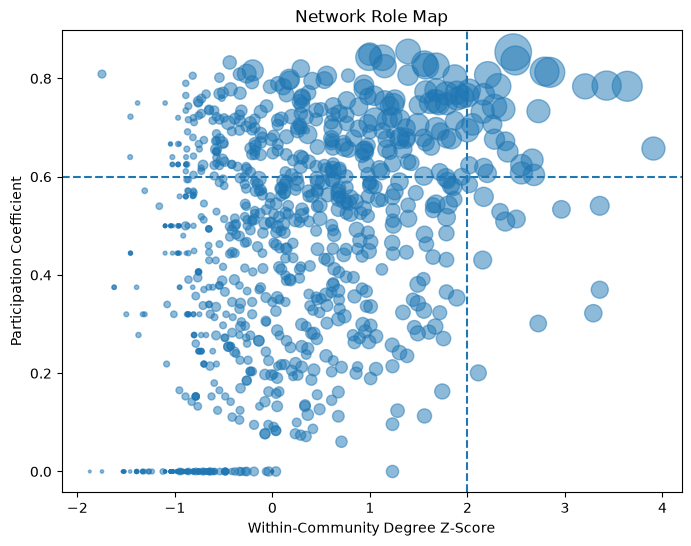

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    role_df["within_degree_z"],
    role_df["participation"],
    s=(
        role_df["degree"] + 1
    ) * 2,
    alpha=0.5
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.axhline(
    0.60,
    linestyle="--"
)

plt.title("Network Role Map")
plt.xlabel("Within-Community Degree Z-Score")
plt.ylabel("Participation Coefficient")
plt.show()

## Hubs and bridges 

Node 160 was the strongest overall communication hub.

It had:

- Department: 36
- Community: 4
- Degree: 345
- PageRank: 0.009410
- Approximate betweenness: 0.089576
- Participation coefficient: 0.853636
- Role: Connector hub

Node 160 had the highest degree, PageRank, and approximate betweenness score. Its high participation coefficient also shows that its connections were distributed across several communities rather than concentrated in one group.

Node 533 had the highest participation coefficient among the displayed bridge candidates:

- Degree: 157
- External connections: 125
- Participation coefficient: 0.854883
- Role: Bridge member

This illustrates the difference between hub and bridge importance. Node 160 was the most influential overall, while Node 533 had a slightly more evenly distributed cross-community connection pattern.

In [34]:
number_of_communities = len(
    communities
)

interaction_matrix = np.zeros(
    (
        number_of_communities,
        number_of_communities
    ),
    dtype=int
)

for source, target in G.edges():
    source_community = (
        node_to_community[source]
    )

    target_community = (
        node_to_community[target]
    )

    interaction_matrix[
        source_community,
        target_community
    ] += 1

    if (
        source_community
        != target_community
    ):
        interaction_matrix[
            target_community,
            source_community
        ] += 1

In [35]:
interaction_df = pd.DataFrame(
    interaction_matrix,
    index=[
        f"Community {i}"
        for i in range(
            number_of_communities
        )
    ],
    columns=[
        f"Community {i}"
        for i in range(
            number_of_communities
        )
    ]
)

interaction_df

,Community 0,Community 1,Community 2,Community 3,Community 4,Community 5,Community 6,Community 7,Community 8,Community 9,...,Community 18,Community 19,Community 20,Community 21,Community 22,Community 23,Community 24,Community 25,Community 26,Community 27
Community 0,1925,1073,731,590,397,669,252,157,30,0,...,0,0,0,0,0,0,0,0,0,0
Community 1,1073,1122,202,278,266,297,178,39,17,0,...,0,0,0,0,0,0,0,0,0,0
Community 2,731,202,1432,161,117,209,71,78,5,0,...,0,0,0,0,0,0,0,0,0,0
Community 3,590,278,161,1004,381,359,117,22,13,0,...,0,0,0,0,0,0,0,0,0,0
Community 4,397,266,117,381,933,103,62,23,3,0,...,0,0,0,0,0,0,0,0,0,0
Community 5,669,297,209,359,103,1374,63,28,15,0,...,0,0,0,0,0,0,0,0,0,0
Community 6,252,178,71,117,62,63,979,9,2,0,...,0,0,0,0,0,0,0,0,0,0
Community 7,157,39,78,22,23,28,9,256,1,0,...,0,0,0,0,0,0,0,0,0,0
Community 8,30,17,5,13,3,15,2,1,21,0,...,0,0,0,0,0,0,0,0,0,0
Community 9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


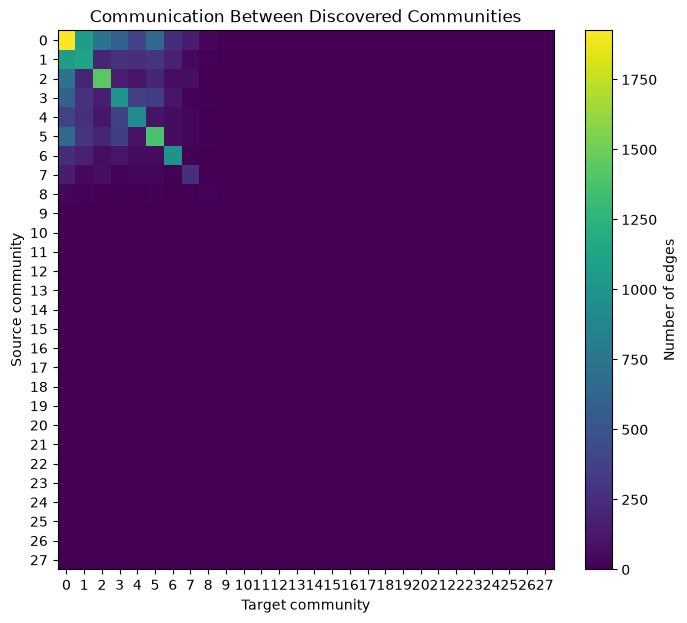

In [36]:
plt.figure(figsize=(8, 7))

plt.imshow(
    interaction_matrix,
    aspect="auto"
)

plt.title("Communication Between Discovered Communities")
plt.xlabel("Target community")
plt.ylabel("Source community")

plt.colorbar(
    label="Number of edges"
)

plt.xticks(
    range(number_of_communities),
    range(number_of_communities)
)

plt.yticks(
    range(number_of_communities),
    range(number_of_communities)
)

plt.show()

## Community interaction 

The interaction matrix showed strong diagonal values, representing communication within the major communities.

The strongest cross-community connection was between Community 0 and Community 1, with 1,073 edges.

Other major cross-community relationships included:

- Community 0 and Community 2: 731 edges
- Community 0 and Community 5: 669 edges
- Community 0 and Community 3: 590 edges
- Community 3 and Community 4: 381 edges
- Community 3 and Community 5: 359 edges

Community 0 acted as a broad communication centre and interacted heavily with several other major groups.

Communities 9 to 27 had no interaction edges because they represented isolated one-member components.

In [37]:
null_graph = G.copy()

number_of_swaps = min(
    2 * G.number_of_edges(),
    50_000
)

nx.double_edge_swap(
    null_graph,
    nswap=number_of_swaps,
    max_tries=number_of_swaps * 20,
    seed=RANDOM_STATE
)

In [38]:
null_communities = (
    nx.community.louvain_communities(
        null_graph,
        resolution=1.0,
        seed=RANDOM_STATE
    )
)

null_modularity = nx.community.modularity(
    null_graph,
    null_communities,
    resolution=1.0
)

null_comparison_df = pd.DataFrame([
    {
        "network": "Observed email network",
        "communities": len(communities),
        "modularity": louvain_modularity
    },
    {
        "network": "Degree-preserving random network",
        "communities": len(
            null_communities
        ),
        "modularity": null_modularity
    }
])

null_comparison_df

,network,communities,modularity
0,Observed email network,28,0.413021
1,Degree-preserving random network,30,0.119694


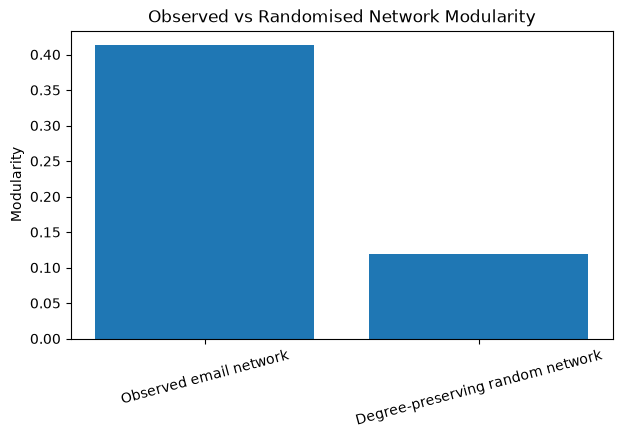

In [39]:
plt.figure(figsize=(7, 4))

plt.bar(
    null_comparison_df["network"],
    null_comparison_df["modularity"]
)

plt.title("Observed vs Randomised Network Modularity")
plt.ylabel("Modularity")
plt.xticks(rotation=15)
plt.show()

## Null-model comparison 

The observed email network achieved a modularity of 0.4130.

The degree-preserving randomised network achieved a modularity of only 0.1197.

The observed modularity was therefore more than three times the random-network value.

Because the randomisation approximately preserved each node's degree, this difference shows that the observed community structure cannot be explained only by the presence of highly connected and weakly connected members. The specific pattern of who communicated with whom created substantially stronger organisation.

This comparison used one randomised graph and should be interpreted as an exploratory null-model test rather than a formal statistical significance result.

In [40]:
final_summary_df = pd.DataFrame({
    "metric": [
        "Nodes",
        "Undirected edges",
        "Connected components",
        "Louvain communities",
        "Louvain modularity",
        "Largest community",
        "Internal edge rate",
        "Department NMI",
        "Department ARI",
        "Weighted community purity",
        "Null-model modularity"
    ],
    "value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.number_connected_components(G),
        len(communities),
        louvain_modularity,
        community_sizes.iloc[0],
        internal_edge_rate,
        department_nmi,
        department_ari,
        weighted_community_purity,
        null_modularity
    ]
})

final_summary_df

,metric,value
0,Nodes,1005.000000
1,Undirected edges,16064.000000
2,Connected components,20.000000
3,Louvain communities,28.000000
4,Louvain modularity,0.413021
5,Largest community,190.000000
6,Internal edge rate,0.563123
7,Department NMI,0.594642
8,Department ARI,0.350454
9,Weighted community purity,0.442786
